<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/IMDB_Top_250_Movies_of_All_Time_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d arnabnahaushna/imdb-top-250-movies-of-all-time

# Unziping the downloaded file
!unzip imdb-top-250-movies-of-all-time.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arnabnahaushna/imdb-top-250-movies-of-all-time
License(s): MIT
  0% 0.00/19.5k [00:00<?, ?B/s]
100% 19.5k/19.5k [00:00<00:00, 55.3MB/s]
Archive:  imdb-top-250-movies-of-all-time.zip
  inflating: IMDB_processed_data.csv  
  inflating: IMDB_processed_data.xlsx  


In [3]:
df = pd.read_csv('IMDB_processed_data.csv')
df.head(11)

,Rank,Title,Release,Runtime,Rated,Ratings
0,1,The Shawshank Redemption,1994,2h 22m,R,9.3
1,2,The Godfather,1972,2h 55m,R,9.2
2,3,The Dark Knight,2008,2h 32m,PG-13,9.0
3,4,The Godfather Part II,1974,3h 22m,R,9.0
4,5,12 Angry Men,1957,1h 36m,Approved,9.0
5,6,The Lord of the Rings: The Return of the King,2003,3h 21m,PG-13,9.0
6,7,Schindler's List,1993,3h 15m,R,9.0
7,8,Pulp Fiction,1994,2h 34m,R,8.9
8,9,The Lord of the Rings: The Fellowship of the Ring,2001,2h 58m,PG-13,8.9
9,10,"The Good, the Bad and the Ugly",1966,2h 58m,R,8.8


In [4]:
df.tail(11)

,Rank,Title,Release,Runtime,Rated,Ratings
239,240,The Iron Giant,1999,1h 26m,PG,8.1
240,241,The Battle of Algiers,1966,2h 1m,Not Rated,8.1
241,242,Into the Wild,2007,2h 28m,R,8.1
242,243,The Grapes of Wrath,1940,2h 9m,Approved,8.1
243,244,Groundhog Day,1993,1h 41m,PG,8.0
244,245,A Man Escaped,1956,1h 41m,Not Rated,8.2
245,246,Amores Perros,2000,2h 34m,R,8.0
246,247,The Help,2011,2h 26m,PG-13,8.1
247,248,Rebecca,1940,2h 10m,Approved,8.1
248,249,A Silent Voice: The Movie,2016,2h 10m,Not Rated,8.1


In [6]:
df.shape

(250, 6)

In [7]:
df.columns

Index(['Rank', 'Title', 'Release', 'Runtime', 'Rated', 'Ratings'], dtype='object')

In [8]:
df.dtypes

,0
Rank,int64
Title,object
Release,int64
Runtime,object
Rated,object
Ratings,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rank     250 non-null    int64  
 1   Title    250 non-null    object 
 2   Release  250 non-null    int64  
 3   Runtime  250 non-null    object 
 4   Rated    250 non-null    object 
 5   Ratings  250 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 11.8+ KB


In [10]:
df.describe(include = 'all')

,Rank,Title,Release,Runtime,Rated,Ratings
count,250.000000,250,250.00000,250,250,250.000000
unique,NaN,250,NaN,100,8,NaN
top,NaN,The Shawshank Redemption,NaN,2h 10m,R,NaN
freq,NaN,1,NaN,10,101,NaN
mean,125.500000,NaN,1988.17200,NaN,NaN,8.310000
std,72.312977,NaN,25.59631,NaN,NaN,0.232716
min,1.000000,NaN,1921.00000,NaN,NaN,8.000000
25%,63.250000,NaN,1971.25000,NaN,NaN,8.100000
50%,125.500000,NaN,1995.00000,NaN,NaN,8.200000
75%,187.750000,NaN,2008.75000,NaN,NaN,8.400000


In [11]:
df.isnull().sum()

,0
Rank,0
Title,0
Release,0
Runtime,0
Rated,0
Ratings,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

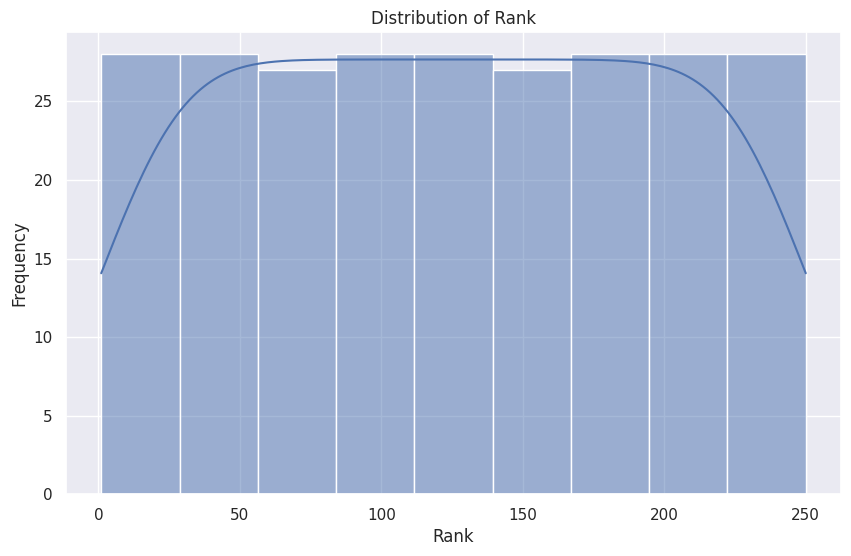

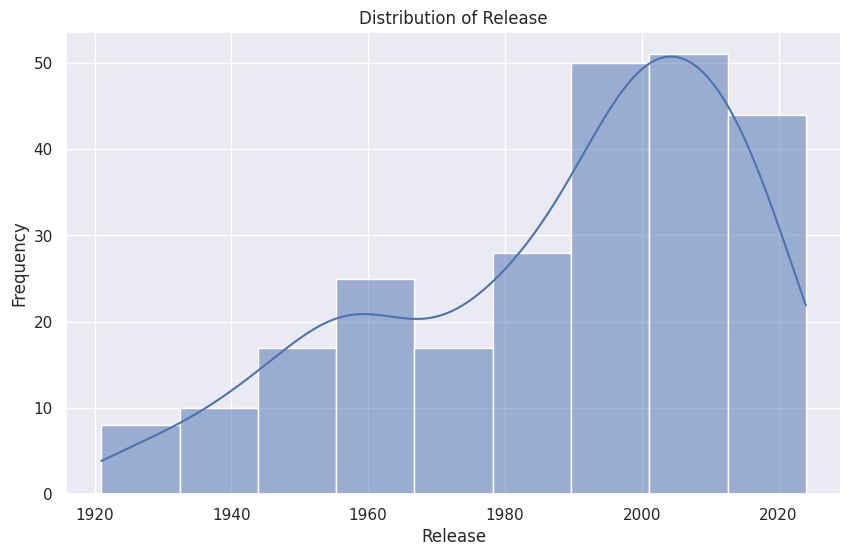

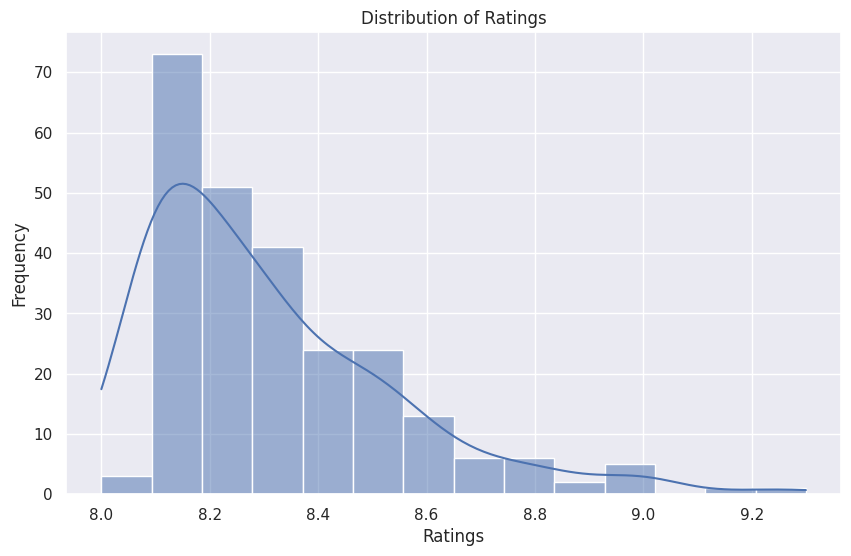

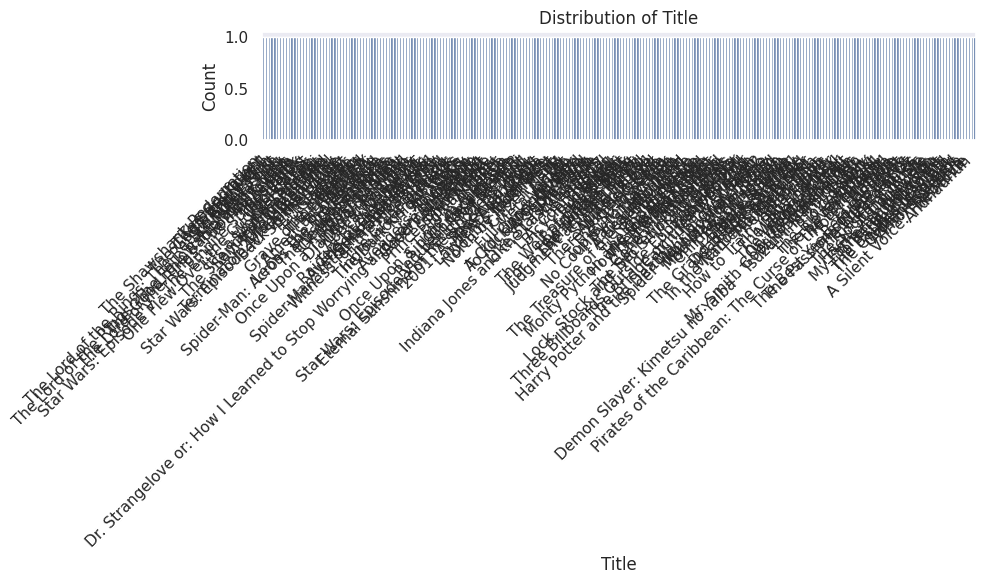

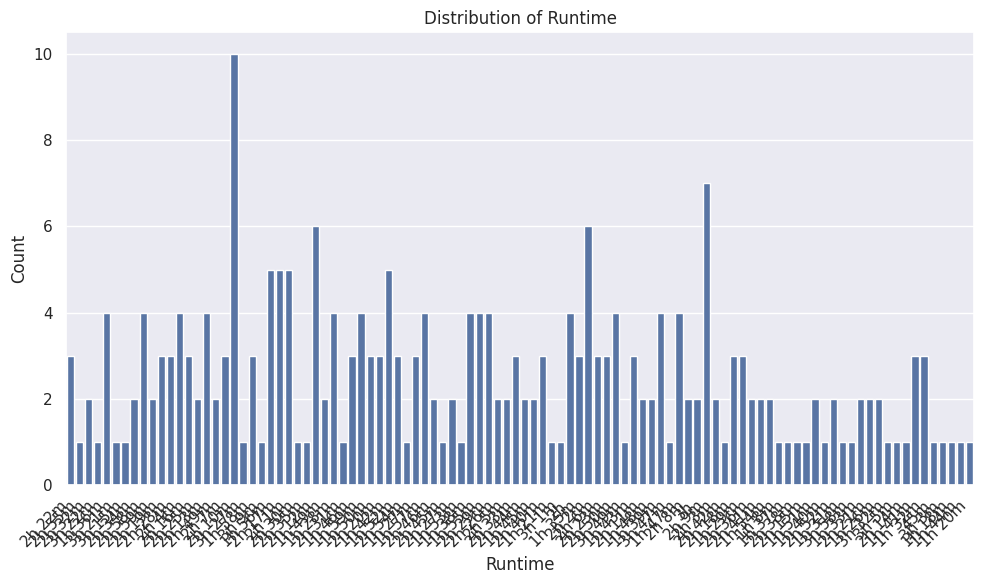

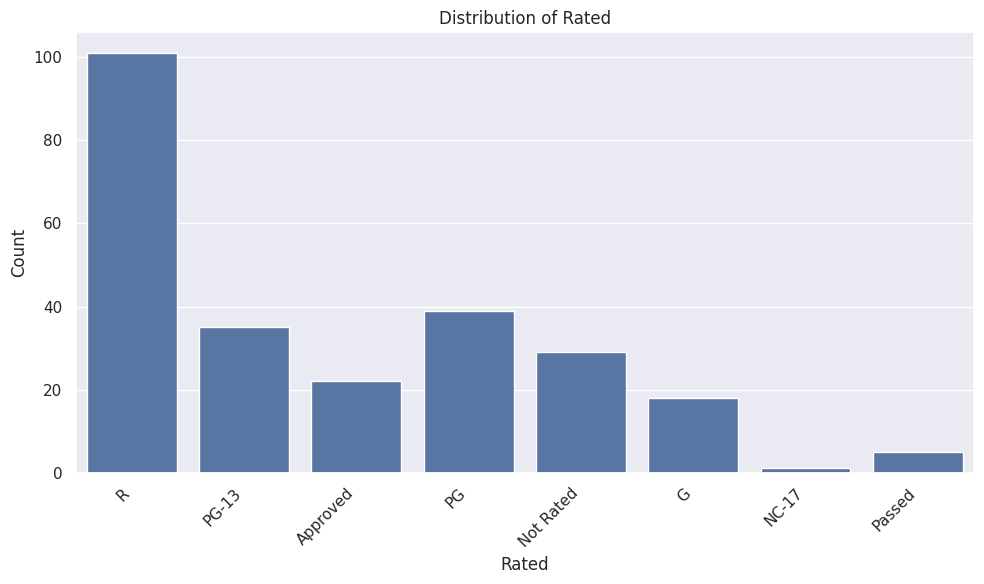

Value counts for Title:
Title
The Shawshank Redemption     1
The Godfather                1
The Dark Knight              1
The Godfather Part II        1
12 Angry Men                 1
                            ..
Amores Perros                1
The Help                     1
Rebecca                      1
A Silent Voice: The Movie    1
Andhadhun                    1
Name: count, Length: 250, dtype: int64

Value counts for Runtime:
Runtime
2h 10m    10
2h 9m      7
2h 2m      6
2h 12m     6
1h 56m     5
          ..
45m        1
3h 3m      1
1h 18m     1
1h 44m     1
1h 20m     1
Name: count, Length: 100, dtype: int64

Value counts for Rated:
Rated
R            101
PG            39
PG-13         35
Not Rated     29
Approved      22
G             18
Passed         5
NC-17          1
Name: count, dtype: int64



In [13]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterating through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Here we can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

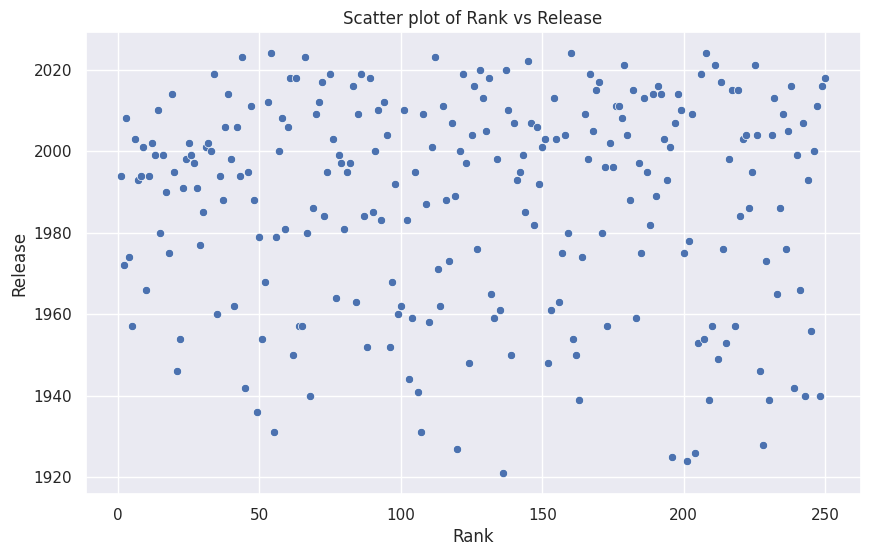

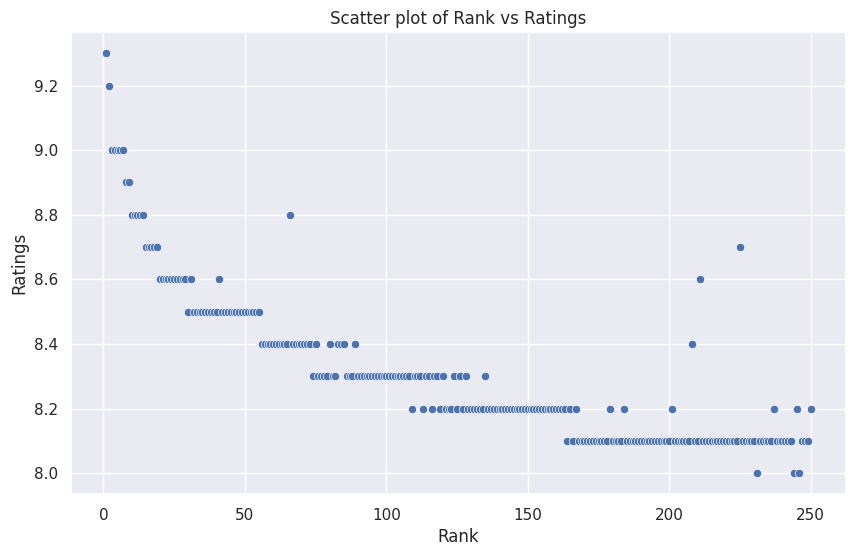

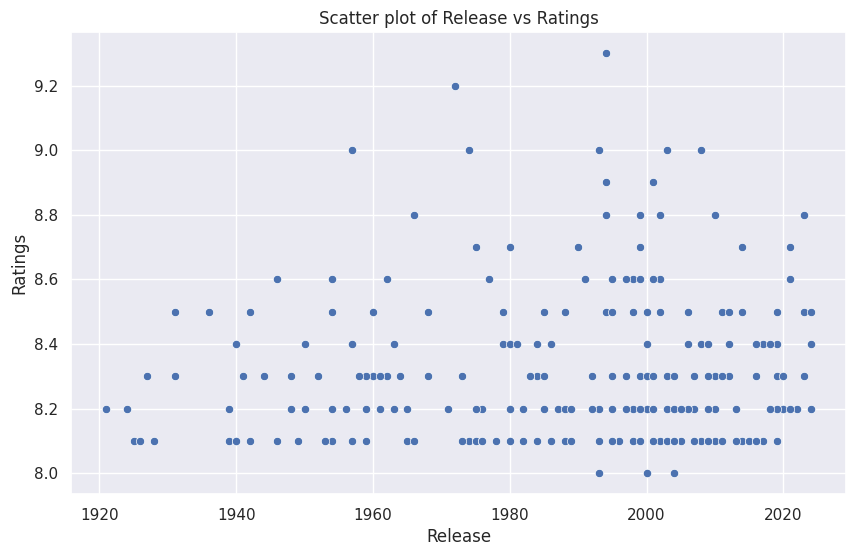

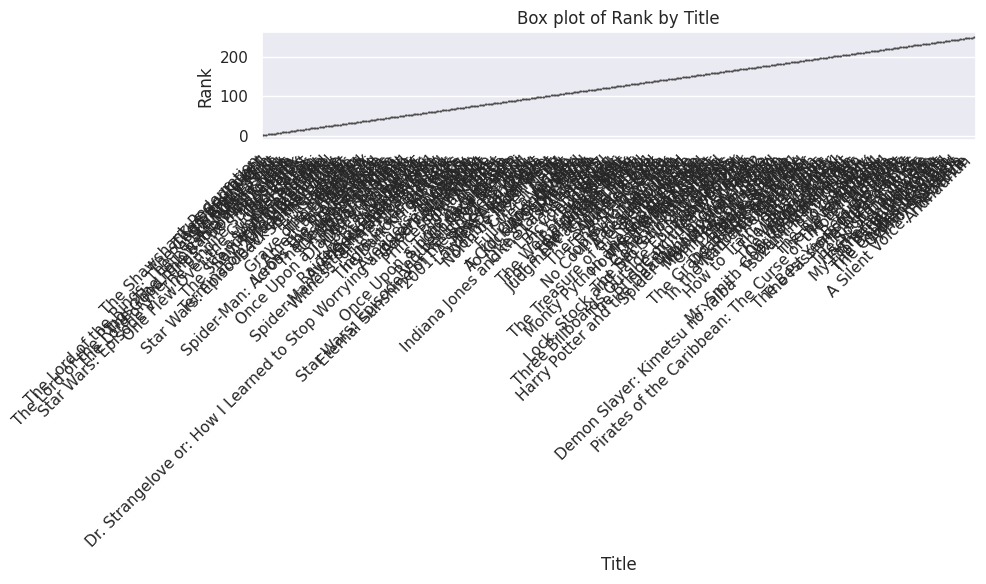

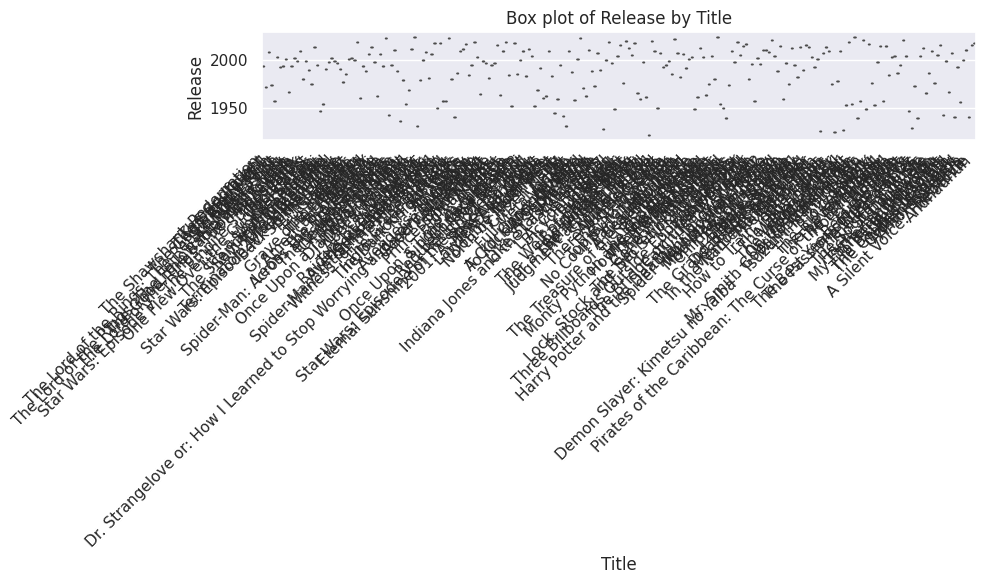

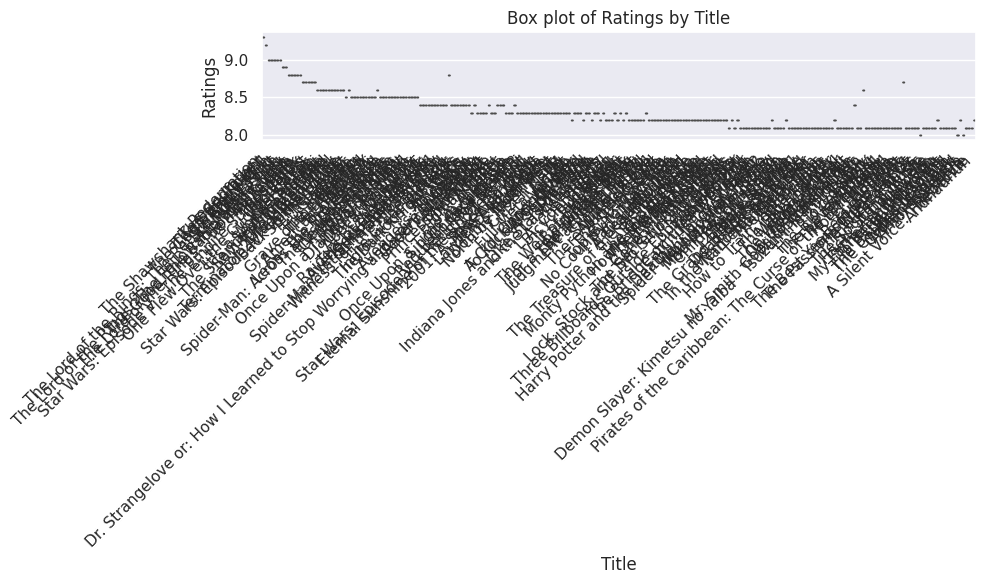

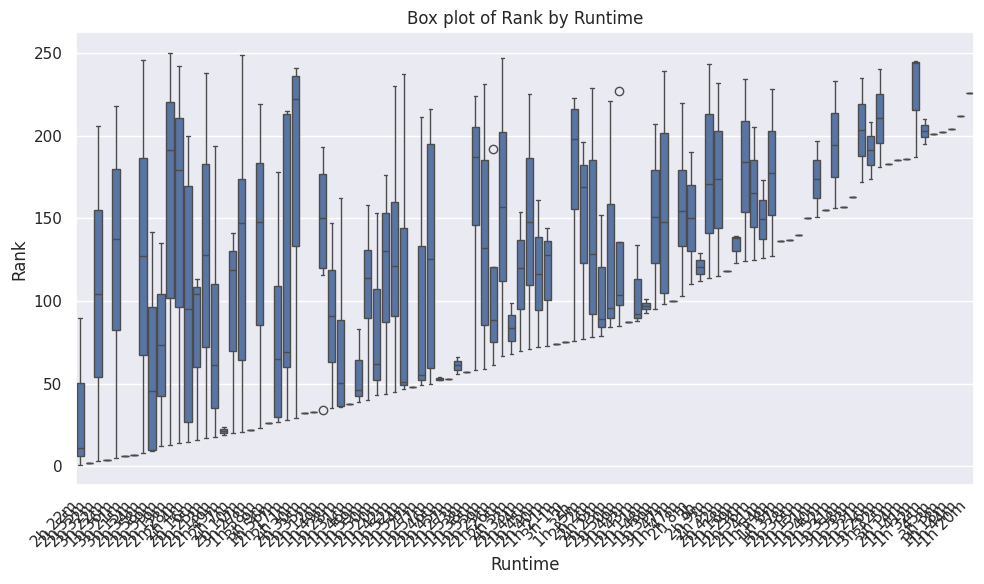

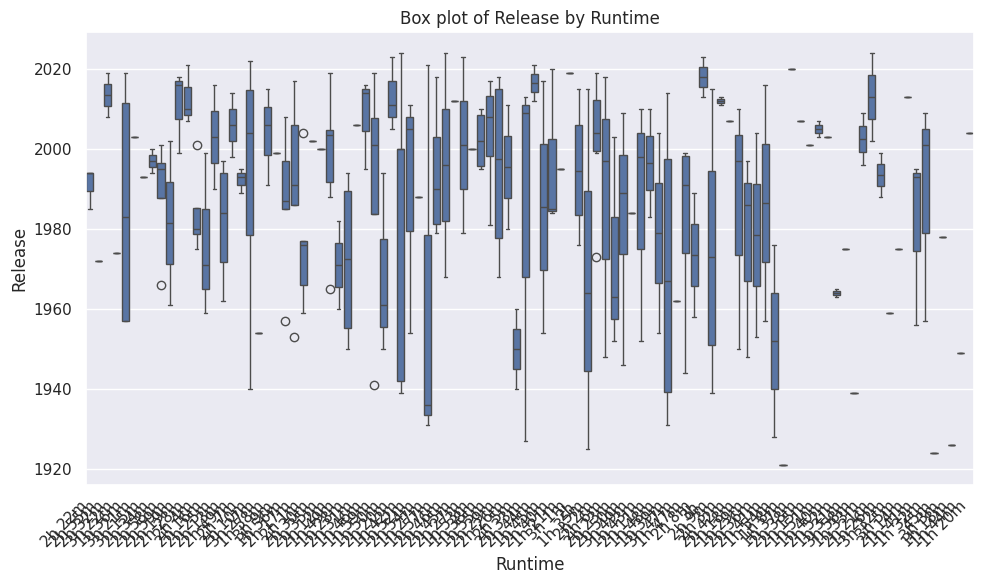

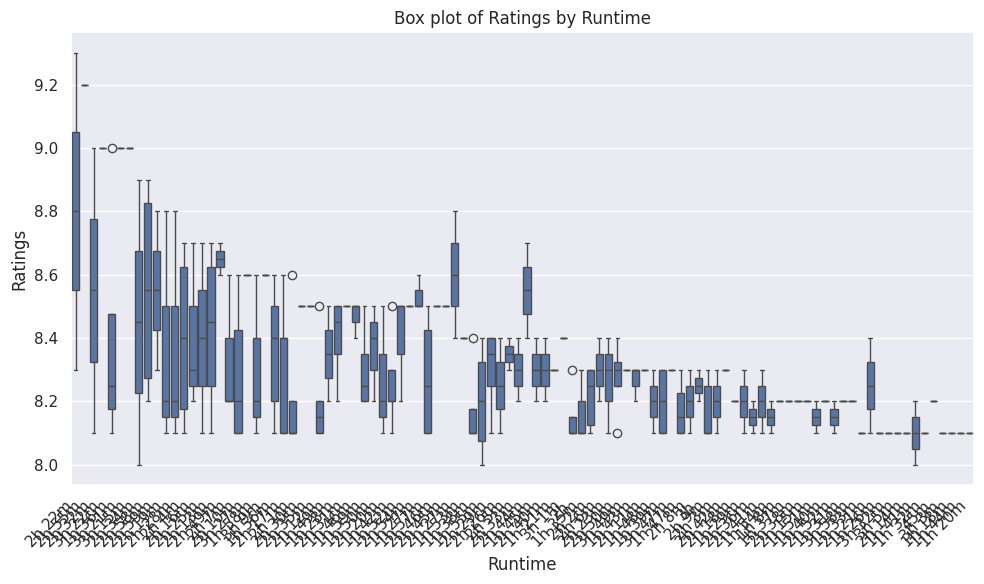

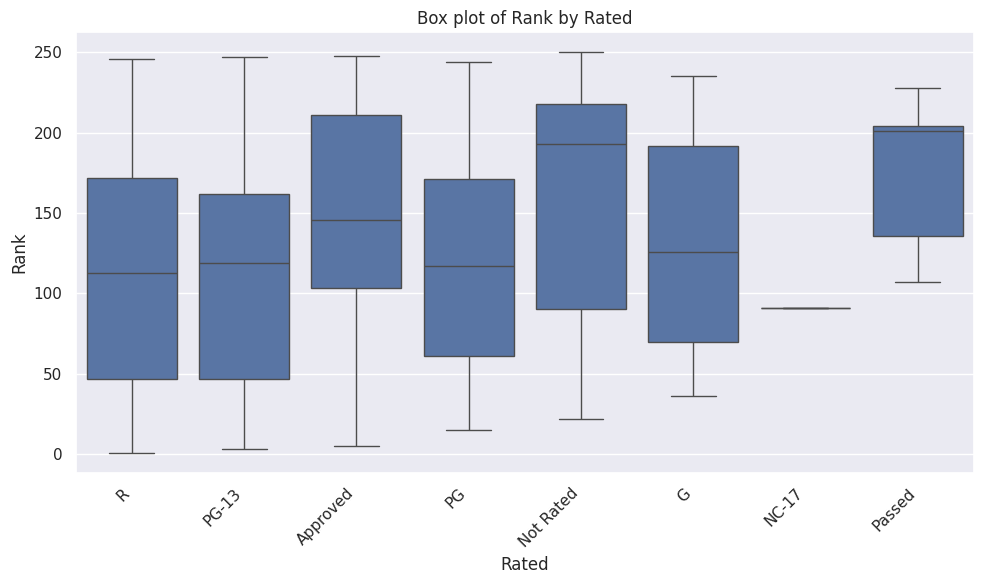

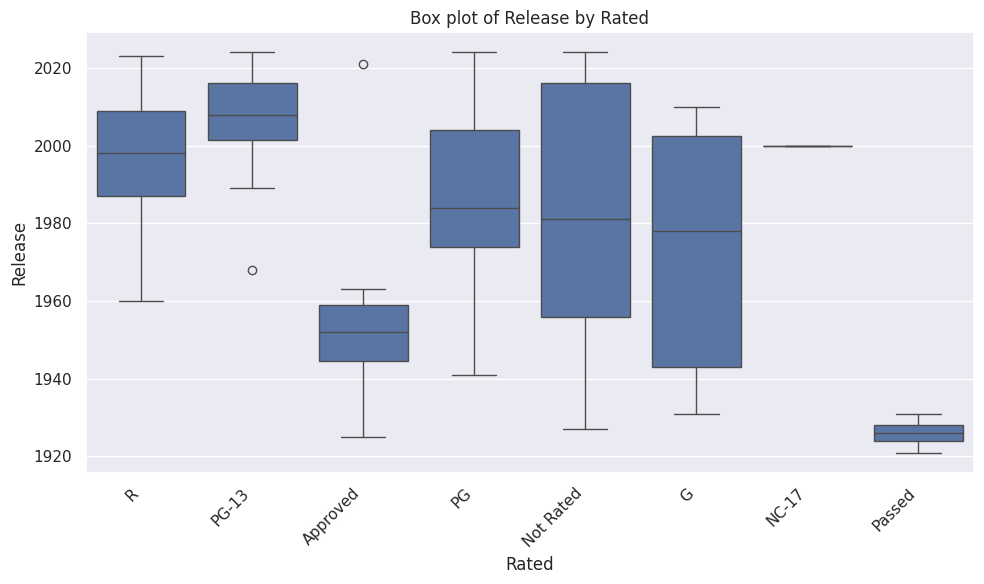

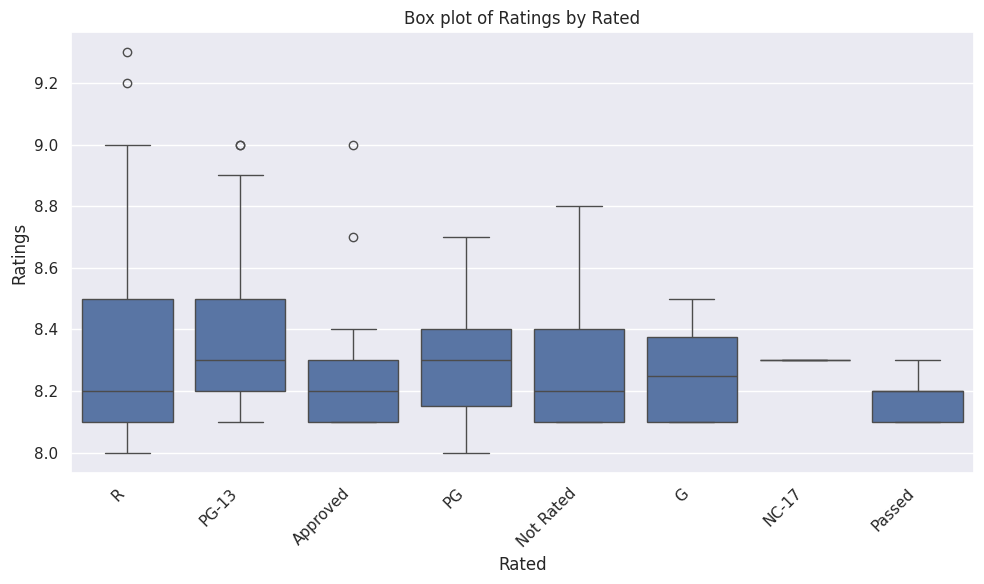

In [14]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

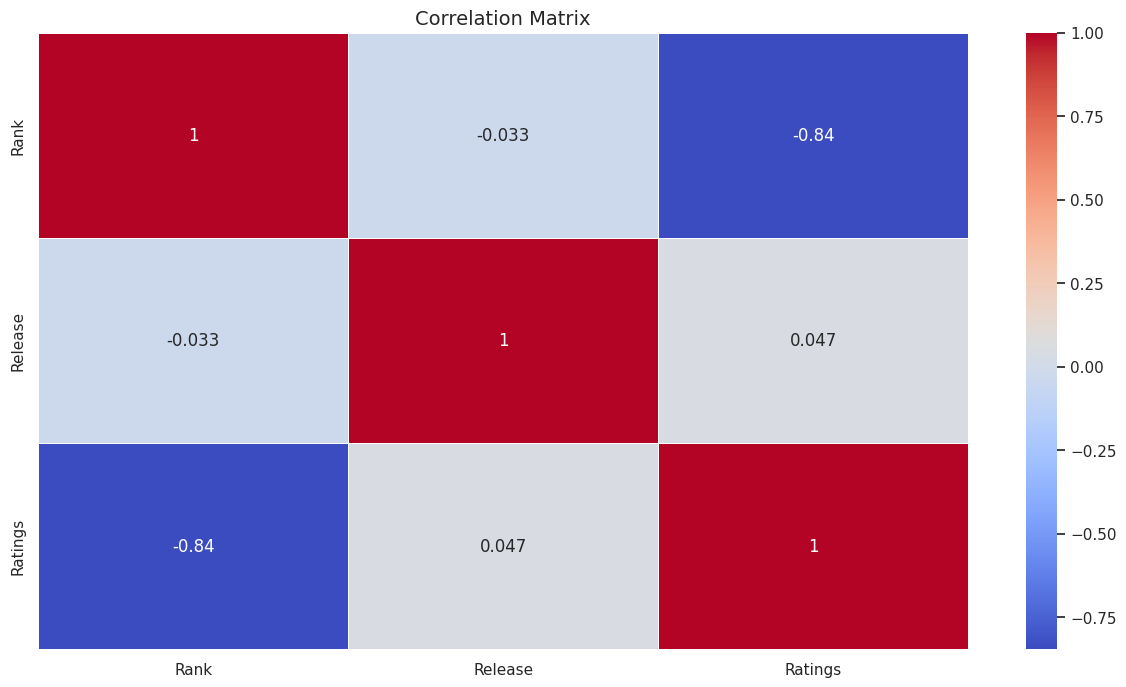

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()